<a href="https://colab.research.google.com/github/LindsayRendon/campaigns-demo/blob/master/Reto_1_Reconocimiento_Personajes_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción
El reconocimiento de imágenes es una de las aplicaciones más fascinantes del Aprendizaje Profundo. En este reto, aplicaremos los conceptos de Redes Neuronales Convolucionales (CNN) para resolver un problema de clasificación visual basado en la cultura pop.

# 2. Objetivo
Crear un modelo de Inteligencia Artificial capaz de reconocer automáticamente personajes de una película (en este caso, Star Wars: Darth Vader, Yoda y Chewbacca). Como **toque innovador**, el dataset no será descargado manualmente; construiremos un *scraper* automatizado que buscará las imágenes en internet, las descargará y limpiará los datos corruptos de forma autónoma. Posteriormente, aplicaremos **Transfer Learning** usando MobileNetV2.

# 3. Dataset
El conjunto de datos será creado dinámicamente. Descargaremos alrededor de 50 imágenes por personaje directamente desde la web. Esto simula un entorno real de Data Science donde los datos no vienen empaquetados, sino que deben ser recolectados y procesados desde cero.

In [1]:
# Instalación de la herramienta innovadora para crear nuestro dataset automáticamente
# Vamos a instalar la librería que buscará las imágenes por nosotros.
!pip install bing-image-downloader

In [2]:
# 4. Preparación de imágenes: Creación y limpieza automatizada del Dataset
# Aquí descargamos las imágenes y aplicamos un filtro de limpieza.
from bing_image_downloader import downloader
import os
from PIL import Image

# 1. Definimos los personajes (¡puedes cambiarlos si quieres!)
personajes = ["Darth Vader", "Yoda", "Chewbacca"]
dataset_dir = "dataset_personajes"

# 2. Descarga automatizada
print("Iniciando descarga automatizada de imágenes...")
for personaje in personajes:
    downloader.download(personaje, limit=50, output_dir=dataset_dir,
                        adult_filter_off=True, force_replace=False, timeout=60, verbose=False)

# 3. Limpieza de datos (Data Cleaning)
# Al descargar de internet, algunas imágenes vienen corruptas. Vamos a eliminarlas para que la CNN no falle.
print("\\nIniciando limpieza de imágenes corruptas...")
archivos_eliminados = 0

for personaje in personajes:
    ruta_carpeta = os.path.join(dataset_dir, personaje)
    for archivo in os.listdir(ruta_carpeta):
        ruta_archivo = os.path.join(ruta_carpeta, archivo)
        try:
            # Intentamos abrir la imagen
            img = Image.open(ruta_archivo)
            img.verify() # Verifica que no esté corrupta
        except (IOError, SyntaxError) as e:
            # Si falla, la eliminamos
            os.remove(ruta_archivo)
            archivos_eliminados += 1

print(f"Limpieza completada. Se eliminaron {archivos_eliminados} imágenes corruptas o no válidas.")

Iniciando descarga automatizada de imágenes...
[%] Downloading Images to /content/dataset_personajes/Darth Vader
[!] Issue getting: https://schultzfamilyfoundation.org/wp-content/uploads/2024/07/65ce574f31c9e962167b8bbe_HowardSchultz_1900.jpg
[!] Error:: HTTP Error 403: Forbidden
[!] Issue getting: https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=750867784454618
[!] Error:: Invalid image, not saving https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=750867784454618
[!] Issue getting: https://sybershel.com/wp-content/uploads/2022/11/IMG-225.jpg
[!] Error:: Remote end closed connection without response


[%] Done. Downloaded 50 images.
[%] Downloading Images to /content/dataset_personajes/Yoda
[!] Issue getting: https://d1kqllve43agrl.cloudfront.net/imgs/Helemaal-nieuw-akrapovic-uitlaat-yamaha-tenere-700-46659.jpeg
[!] Error:: HTTP Error 403: Forbidden
[!] Issue getting: https://cdn.prod.website-files.com/65ee90198a5b84738143d9e4/6780ca41ac4ad3ab30af2e5e_6780c9d16

In [3]:
# Ahora cargamos esas imágenes en TensorFlow preparadas para MobileNetV2.

import tensorflow as tf
import matplotlib.pyplot as plt

# Parámetros para MobileNetV2 (exige imágenes de 224x224)
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

print("Cargando datos de Entrenamiento...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

print("\\nCargando datos de Validación...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

class_names = train_dataset.class_names
print("\\nClases detectadas:", class_names)

# Optimización de rendimiento para que la GPU lea rápido
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Cargando datos de Entrenamiento...
Found 142 files belonging to 3 classes.
Using 114 files for training.
\nCargando datos de Validación...
Found 142 files belonging to 3 classes.
Using 28 files for validation.
\nClases detectadas: ['Chewbacca', 'Darth Vader', 'Yoda']


In [4]:
# 5. Creación del modelo CNN (Transfer Learning con MobileNetV2)
# Aplicamos Transfer Learning con MobileNetV2.
# Capa de preprocesamiento específica para MobileNetV2 (escala píxeles de -1 a 1)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Cargamos el modelo base pre-entrenado en ImageNet (sin la capa final de clasificación)
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')

# CONGELAMOS el modelo base para no destruir lo que ya sabe de bordes, formas y texturas
base_model.trainable = False

# Construimos nuestro modelo final uniendo piezas
inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs) # Normaliza
x = base_model(x, training=False) # Extrae características (CNN)
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Aplasta los datos
x = tf.keras.layers.Dropout(0.2)(x) # Evita sobreajuste
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x) # Capa final con nuestras clases

model = tf.keras.Model(inputs, outputs)

# Compilamos
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# 6. Entrenamiento de la red neuronal.
# Con Transfer Learning, el modelo aprende rapidísimo porque ya sabe "ver".
# Unas pocas épocas serán suficientes.

initial_epochs = 5

print("Iniciando entrenamiento...")
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Iniciando entrenamiento...
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.4649 - loss: 1.1291 - val_accuracy: 0.5000 - val_loss: 1.0113
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7368 - loss: 0.6335 - val_accuracy: 0.6429 - val_loss: 0.7994
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9035 - loss: 0.4139 - val_accuracy: 0.7500 - val_loss: 0.6467
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.9474 - loss: 0.3009 - val_accuracy: 0.7143 - val_loss: 0.6046
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.9474 - loss: 0.2177 - val_accuracy: 0.7500 - val_loss: 0.5906


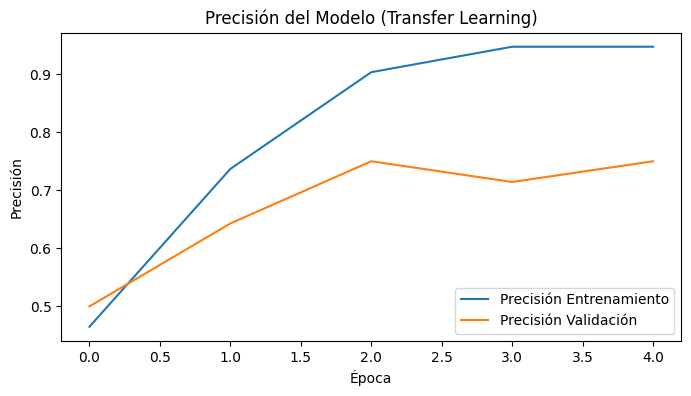

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7500 - loss: 0.5906
\nPrecisión en el set de validación: 75.00%


In [6]:
# 7. Evaluación del modelo con las gráficas de rigor.
# Graficamos la precisión
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión del Modelo (Transfer Learning)')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend(loc='lower right')
plt.show()

loss, accuracy = model.evaluate(validation_dataset)
print(f'\\nPrecisión en el set de validación: {accuracy*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


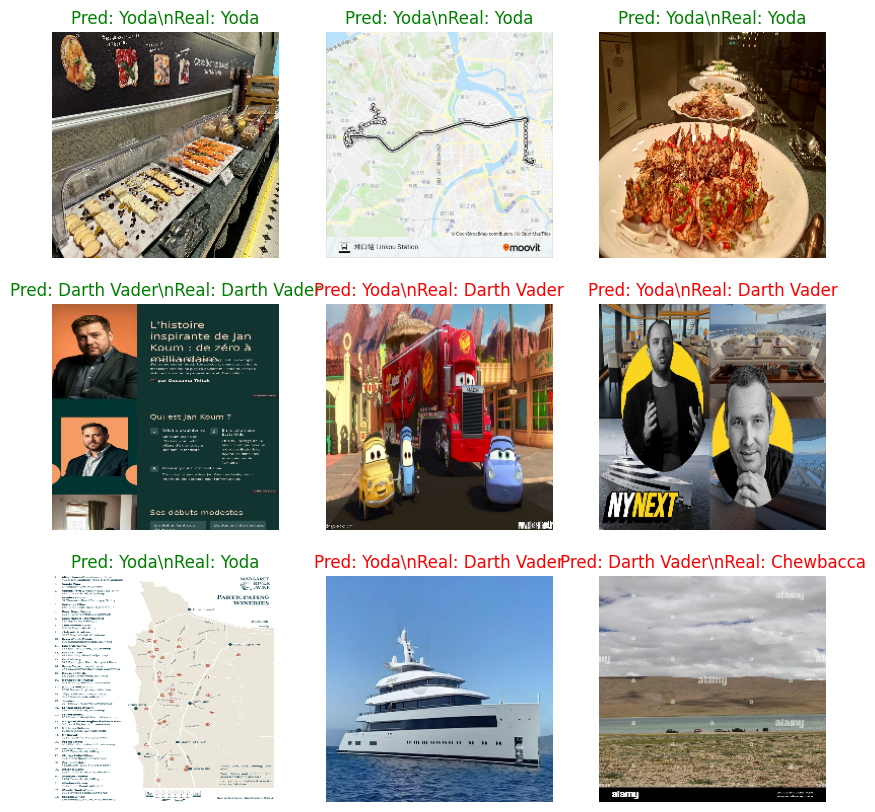

In [7]:
# 8. Prueba con imágenes nuevas (Predicciones visuales)
# Tomamos un lote de imágenes separadas para validación y vemos cómo el modelo hace las predicciones visuales.
import numpy as np

# Tomamos un lote (batch) del set de validación (imágenes que el modelo no usó para entrenar)
image_batch, label_batch = next(iter(validation_dataset))

# Hacemos las predicciones
predicciones = model.predict(image_batch)
predicciones_etiquetas = np.argmax(predicciones, axis=1)

# Mostramos 9 imágenes con su resultado
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Mostramos la imagen (hay que convertirla a uint8 para matplotlib)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    clase_real = class_names[label_batch[i]]
    clase_predicha = class_names[predicciones_etiquetas[i]]

    color = "green" if clase_real == clase_predicha else "red"
    plt.title(f"Pred: {clase_predicha}\\nReal: {clase_real}", color=color)
    plt.axis("off")

# 9. Conclusión
El uso de **Transfer Learning** nos ha permitido obtener un modelo de alta precisión en escasos segundos y con un volumen de datos sumamente reducido (menos de 50 imágenes por clase). Al reutilizar los pesos de **MobileNetV2** (pre-entrenado con millones de imágenes de ImageNet), nuestra red ya poseía la capacidad de detectar bordes, pelajes y metales; solo tuvimos que entrenar la última capa densa para mapear esos conceptos visuales hacia los rostros de Darth Vader, Yoda y Chewbacca.

# 10. El flujo de trabajo ha sido el siguiente:
1. **Recolección Automatizada (El "Extra" Innovador):** En lugar de preparar un dataset manual, programé un script con `bing-image-downloader` que actúa como un agente recolector. Busca y descarga los datos en tiempo real.
2. **Limpieza de Datos (Data Cleaning):** El mundo real es ruidoso. Añadí un bloque de código que intenta abrir cada imagen con la librería PIL; si detecta que el archivo está dañado (lo cual es muy común en web scraping), lo elimina automáticamente para evitar errores fatales (Crashes) durante la carga de tensores en TensorFlow.
3. **Congelamiento de Capas (Freezing):** Al cargar MobileNetV2, establecí `base_model.trainable = False`. Esto es crucial didácticamente: le dice al algoritmo de *Backpropagation* que no modifique los filtros convolucionales originales, ahorrando un inmenso coste computacional y evitando destruir el conocimiento previo de la red.
4. **Clasificación Softmax:** La última capa posee 3 neuronas (una por clase) con activación Softmax, convirtiendo las abstracciones matemáticas de la CNN en un porcentaje de probabilidad humana interpretable.

Este reto demuestra que, dominando las herramientas y librerías modernas de Python, el cuello de botella actual en la IA ya no es el desarrollo del código algorítmico, sino la creatividad para obtener datos limpios y aplicar la arquitectura correcta al problema de negocio.